In [1]:
#Traffic analysis 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import warnings

In [2]:
df = pd.read_excel('/Users/thomas/Data/Dynamic_weight_data/Marzo/1 marzo - 7 marzo/2.xlsx')
df.head(10)

,Id,StartTime,StartTimeStr,LaneNo,LaneName,BaseClassId,Scheme,ClassId,MoveStatus,FrontToFront,...,WheelBase,FrontOverhang,AxlesCount,MassUnit,VelocityUnit,DistanceUnit,WheelType,StrongAcceleration,StrongDeceleration,DateTimeTransit
0,738780,1741220000000,2025-06-03 00:16:00,2,Corsia 1 - Marcia,19,EUR13,12,-1,263.822,...,6.09,1.13,2,kg,km/h,m,D,0,0,2025-06-03 00:16:00
1,738860,1741220000000,2025-06-03 01:31:00,3,Corsia 2 - Marcia veloce,21,EUR13,1,1,188.386,...,2.80,0.39,2,kg,km/h,m,N,0,0,2025-06-03 01:31:00
2,738906,1741230000000,2025-06-03 02:19:00,2,Corsia 1 - Marcia,15,EUR13,9,-1,394.219,...,11.81,1.14,5,kg,km/h,m,D,0,0,2025-06-03 02:19:00
3,759360,1741310000000,2025-07-03 00:08:00,2,Corsia 1 - Marcia,15,EUR13,9,-1,398.533,...,11.60,1.43,5,kg,km/h,m,D,0,0,2025-07-03 00:08:00
4,759382,1741310000000,2025-07-03 00:32:00,3,Corsia 2 - Marcia veloce,21,EUR13,1,-1,344.737,...,2.92,0.16,2,kg,km/h,m,N,0,0,2025-07-03 00:32:00
5,759419,1741310000000,2025-07-03 01:09:00,2,Corsia 1 - Marcia,21,EUR13,1,-1,265.508,...,2.80,0.45,2,kg,km/h,m,S,0,0,2025-07-03 01:09:00
6,759431,1741310000000,2025-07-03 01:20:00,2,Corsia 1 - Marcia,15,EUR13,9,1,140.339,...,12.04,1.28,5,kg,km/h,m,D,0,0,2025-07-03 01:20:00
7,759471,1741310000000,2025-07-03 01:50:00,2,Corsia 1 - Marcia,14,EUR13,8,1,349.177,...,12.12,1.26,4,kg,km/h,m,D,0,0,2025-07-03 01:50:00
8,780997,1741400000000,2025-08-03 01:48:00,3,Corsia 2 - Marcia veloce,21,EUR13,1,-1,351.692,...,2.65,0.29,2,kg,km/h,m,N,0,0,2025-08-03 01:48:00
9,781003,1741400000000,2025-08-03 01:56:00,3,Corsia 2 - Marcia veloce,21,EUR13,1,1,281.426,...,2.64,0.03,2,kg,km/h,m,N,0,0,2025-08-03 01:56:00


In [280]:
df['ClassId'].unique()

array([12,  1,  9,  8,  2, 13,  5,  3,  6, 10,  4,  7, 11])

In [281]:
df.groupby(by='ClassId').count()

,Id,StartTime,StartTimeStr,LaneNo,LaneName,BaseClassId,Scheme,MoveStatus,FrontToFront,BackToFront,Duration,VehicleLength,GrossWeight,LeftWeight,RightWeight,Velocity,WheelBase,FrontOverhang,AxlesCount,MassUnit,VelocityUnit,DistanceUnit,WheelType,StrongAcceleration,StrongDeceleration,DateTimeTransit
ClassId,,,,,,,,,,,,,,,,,,,,,,,,,,
1,52479,52479,52479,52479,52479,52479,52479,52479,52479,52479,52479,52479,52479,52479,52479,52479,52479,52479,52479,52479,52479,52479,52479,52479,52479,52479
2,3801,3801,3801,3801,3801,3801,3801,3801,3801,3801,3801,3801,3801,3801,3801,3801,3801,3801,3801,3801,3801,3801,3801,3801,3801,3801
3,277,277,277,277,277,277,277,277,277,277,277,277,277,277,277,277,277,277,277,277,277,277,277,277,277,277
4,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78,78
5,201,201,201,201,201,201,201,201,201,201,201,201,201,201,201,201,201,201,201,201,201,201,201,201,201,201
6,220,220,220,220,220,220,220,220,220,220,220,220,220,220,220,220,220,220,220,220,220,220,220,220,220,220
7,137,137,137,137,137,137,137,137,137,137,137,137,137,137,137,137,137,137,137,137,137,137,137,137,137,137
8,2186,2186,2186,2186,2186,2186,2186,2186,2186,2186,2186,2186,2186,2186,2186,2186,2186,2186,2186,2186,2186,2186,2186,2186,2186,2186
9,6280,6280,6280,6280,6280,6280,6280,6280,6280,6280,6280,6280,6280,6280,6280,6280,6280,6280,6280,6280,6280,6280,6280,6280,6280,6280


In [282]:
df.head()

,Id,StartTime,StartTimeStr,LaneNo,LaneName,BaseClassId,Scheme,ClassId,MoveStatus,FrontToFront,BackToFront,Duration,VehicleLength,GrossWeight,LeftWeight,RightWeight,Velocity,WheelBase,FrontOverhang,AxlesCount,MassUnit,VelocityUnit,DistanceUnit,WheelType,StrongAcceleration,StrongDeceleration,DateTimeTransit
0,738780,1741220000000,2025-06-03 00:16:00,2,Corsia 1 - Marcia,19,EUR13,12,-1,263.822,263.017,0.631,10.48,12100,5950,6150,88,6.09,1.13,2,kg,km/h,m,D,0,0,2025-06-03 00:16:00
1,738860,1741220000000,2025-06-03 01:31:00,3,Corsia 2 - Marcia veloce,21,EUR13,1,1,188.386,188.158,0.322,4.65,1870,990,880,113,2.80,0.39,2,kg,km/h,m,N,0,0,2025-06-03 01:31:00
2,738906,1741230000000,2025-06-03 02:19:00,2,Corsia 1 - Marcia,15,EUR13,9,-1,394.219,393.967,0.920,16.87,25520,12820,12700,86,11.81,1.14,5,kg,km/h,m,D,0,0,2025-06-03 02:19:00
3,759360,1741310000000,2025-07-03 00:08:00,2,Corsia 1 - Marcia,15,EUR13,9,-1,398.533,398.377,0.881,15.53,46830,22890,23940,88,11.60,1.43,5,kg,km/h,m,D,0,0,2025-07-03 00:08:00
4,759382,1741310000000,2025-07-03 00:32:00,3,Corsia 2 - Marcia veloce,21,EUR13,1,-1,344.737,344.605,0.198,4.87,2610,1430,1180,175,2.92,0.16,2,kg,km/h,m,N,0,0,2025-07-03 00:32:00


In [283]:
df = df[df['GrossWeight'] > 30000]


#df = df[df['ClassId'] == 13]

df['momentum'] = df['GrossWeight'] * df['Velocity']

print(df['GrossWeight'].max())
print(df['GrossWeight'].min())
print(df['GrossWeight'].mean())
print(df['Velocity'].max())
print(df['Velocity'].min())
print(df['Velocity'].mean())

print(df.shape)

64660
30020
39936.66948198198
99
68
87.759009009009
(3552, 28)


In [284]:
df_mom = df['momentum']
df_mom.astype(int)

#print(df_mom.describe())

print(df_mom.max())

print(df_mom.min())

5860400
2264400


Axes(0.125,0.11;0.775x0.77)


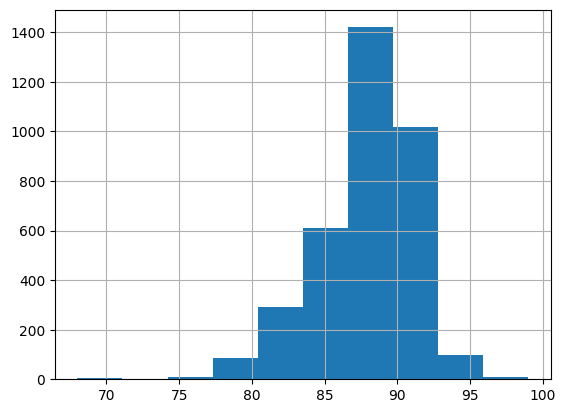

In [285]:

#print(df['GrossWeight'].hist()) 
print(df['Velocity'].hist())

#print(df['momentum'].hist())



In [286]:
df.groupby(by='ClassId').count()

,Id,StartTime,StartTimeStr,LaneNo,LaneName,BaseClassId,Scheme,MoveStatus,FrontToFront,BackToFront,Duration,VehicleLength,GrossWeight,LeftWeight,RightWeight,Velocity,WheelBase,FrontOverhang,AxlesCount,MassUnit,VelocityUnit,DistanceUnit,WheelType,StrongAcceleration,StrongDeceleration,DateTimeTransit,momentum
ClassId,,,,,,,,,,,,,,,,,,,,,,,,,,,
3,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1,1
4,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24
5,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24,24
6,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148,148
8,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63,63
9,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184,3184
10,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54,54
11,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7,7
13,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47,47


In [287]:
df = df[1800:2000]


In [ ]:

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)

In [288]:
df_timestamp = df[['StartTimeStr']]
pd.to_datetime(df_timestamp['StartTimeStr'])



24377   2025-06-03 22:45:00
24378   2025-06-03 22:46:00
24379   2025-06-03 22:46:00
24412   2025-06-03 23:03:00
24415   2025-06-03 23:06:00
                ...        
25506   2025-07-03 05:23:00
25508   2025-07-03 05:23:00
25522   2025-07-03 05:24:00
25524   2025-07-03 05:24:00
25527   2025-07-03 05:24:00
Name: StartTimeStr, Length: 200, dtype: datetime64[ns]

In [289]:
df_timestamp.head(50)
#df_timestamp.tail()


,StartTimeStr
24377,2025-06-03 22:45:00
24378,2025-06-03 22:46:00
24379,2025-06-03 22:46:00
24412,2025-06-03 23:03:00
24415,2025-06-03 23:06:00
24445,2025-06-03 23:23:00
24446,2025-06-03 23:25:00
24483,2025-06-03 23:53:00
24485,2025-06-03 23:55:00
24505,2025-07-03 00:18:00


In [ ]:
#df_timestamp.to_csv('timestamps_collection.csv')